In [89]:
import datetime
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter

In [90]:
# with zipfile.ZipFile('./data/Electrodermal Activity artifact correction BEnchmark (EDABE)/EDABE dataset.zip', 'r') as zip_ref:
#     zip_ref.extractall('./data/Electrodermal Activity artifact correction BEnchmark (EDABE)')

In [91]:
# os.remove('./data/Electrodermal Activity artifact correction BEnchmark (EDABE)/Train/')
# os.remove('./data/Electrodermal Activity artifact correction BEnchmark (EDABE)/Test/')

In [92]:
raw_eda_df = pd.read_csv('./data/Electrodermal Activity artifact correction BEnchmark (EDABE)/Corrected_oxused_expert2.csv', sep=';')
raw_eda_df

,time,rawdata,cleandata,binarytarget,signal_automatic,PredArtifacts,PostProcessedPredArtifacts
0,0.000000,0.000000,-0.091119,0.0,0.000000,0.0,0.0
1,0.007812,0.000000,-0.091119,0.0,0.000000,0.0,0.0
2,0.015625,0.000000,-0.091119,0.0,0.000000,0.0,0.0
3,0.023438,0.000000,-0.091119,0.0,0.000000,0.0,0.0
4,0.031250,0.000000,-0.091119,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...
765040,5976.875000,0.011766,0.011766,0.0,0.011766,0.0,0.0
765041,5976.882812,0.011322,0.011322,0.0,0.011322,0.0,0.0
765042,5976.890625,0.011322,0.011322,0.0,0.011322,0.0,0.0
765043,5976.898438,0.011766,0.011766,0.0,0.011766,0.0,0.0


In [93]:
def view_time_frame(raw_eda_df, begin_time_s=1750, end_time_s=1765, ):
    fig = plt.figure(figsize=(17, 5))

    axis = fig.add_subplot()


    # why is it multiplied by 128?
    # results it 224000 and 225920 and is used as indeces to access a slice of the dataframes rows
    begin_sample, end_sample = begin_time_s * 128, end_time_s * 128

    time_to_plot = raw_eda_df["time"].iloc[begin_sample:end_sample]

    rawdata_to_plot = raw_eda_df["rawdata"].iloc[begin_sample:end_sample]
    cleandata_to_plot = raw_eda_df["cleandata"].iloc[begin_sample:end_sample]
    autodata_to_plot = raw_eda_df["signal_automatic"].iloc[begin_sample:end_sample]    

    axis.plot(time_to_plot, rawdata_to_plot, label="Raw data")
    axis.plot(time_to_plot, cleandata_to_plot, label="Manual", c="orange")
    axis.plot(time_to_plot, autodata_to_plot, label="Automatic", alpha=0.7, linestyle="--", c="red")
            
    axis.legend(fontsize=14)
    axis.grid()
            
    axis.set_ylabel(r'$\mu S$', fontsize=16)
    axis.set_xlabel("Time (s)", fontsize=16)

    plt.show()

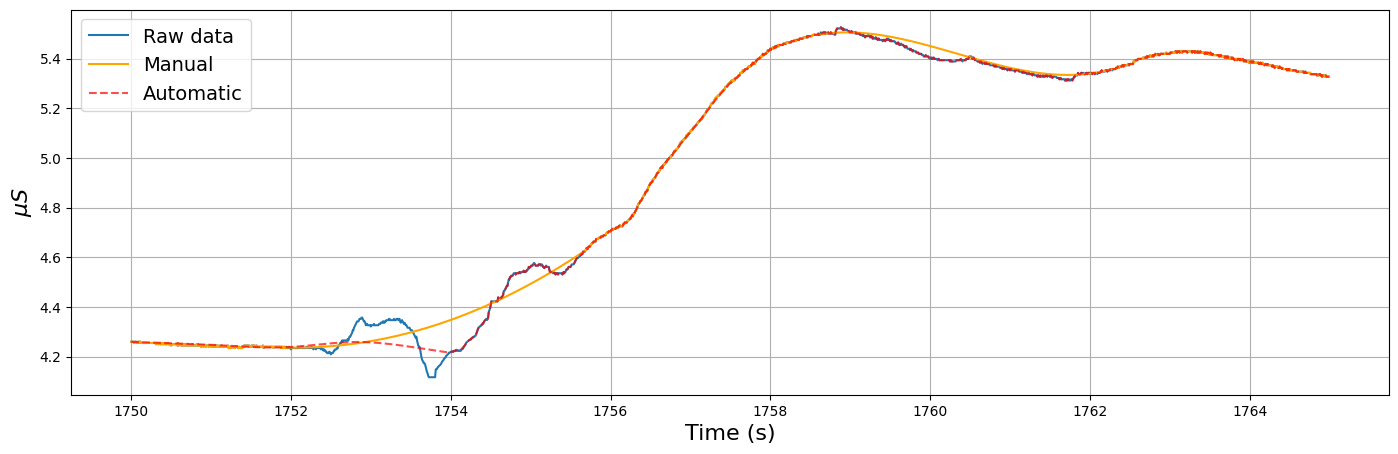

In [94]:
view_time_frame(raw_eda_df, 1750, 1765)

Here we attempt to get the raw SCR values from 0 to 5 seconds

In [95]:
begin_time_s, end_time_s = 0, 5
begin_sample, end_sample = begin_time_s * 128, end_time_s * 128
time_to_plot = raw_eda_df["time"].iloc[begin_sample:end_sample]
time_to_plot

0      0.000000
1      0.007812
2      0.015625
3      0.023438
4      0.031250
         ...   
635    4.960938
636    4.968750
637    4.976562
638    4.984375
639    4.992188
Name: time, Length: 640, dtype: float64

## Oh ok so the reason why it is multiplied by 128 is because since these are values in milliseconds that render it a float value and we want the flexibility to choose letsay sa specific time frame of 1750 to 1765 we cant really index the dataframe with a float value but we can convert the time frame value we want such that we are able to use the resulting value as index that matches exactly the time frame we want to access

In [96]:

def charge_raw_data(df, x_col="rawdata", target_size_frames=64, y_col=None, freq_signal=128, verbose=False):
    """
    charge_raw_data" preprocesses the input signal cutting the signal in pieces of 5 seconds. 
    In the case that a target is introduced i.e. y_col != None, the target is cut the last 0.5 
    seconds of the binary target, becoming the target of the correspondent 5 seconds segement.
    """
    
    # we access the SCR values via raw data column
    x_signal = df[x_col].values

    # here if we would want to create windows of the raw data including the target label
    # we must specify which target label we want to include since there are multiple columns
    # that pertain to the label I vbelieve which are: binary_target, predicted artifacts 
    # and post processed artifacts
    if y_col is not None:
        y_signal = df[y_col].values
    
    window_size = 5 * freq_signal

    x_window_list, y_window_list = [], []
    
    i = 0
    # so if we have a length of 765045 rows for the raw eda data
    # and in each row we'd have to multiply 128 to get specific seconds e.g.
    # to get 0th second we multiply 128 by 0 and use it as index 
    # raw_eda_df['time'].iloc[:128 * 0], to get 1st second mark we'd have
    # to multiply 128 by 1 and use it as index raw_eda_df['time'].iloc[:128 * 1]

    # but what is the point of subtracting 765045 by window size of 640 (5 * 128)?
    print(f'length of x_signals: {len(x_signal)}')
    print(f'window size: {window_size}')
    while i <= len(x_signal) - window_size:
        
        # oh so this is the denominator part of the min max scaling formula
        # and as stated by llanes-jurado et al. they used min max scaling to scale the raw signals
        # mroeover nanmax and min is used in case of nan values in the windows which returns 
        # minimum of an array or minimum along an axis, ignoring any NaNs
        denominator_norm = (np.nanmax(x_signal[i:(i + window_size)]) - np.nanmin(x_signal[i:(i + window_size)]))
        
        # this is full min max scaling formula with the denominator using 
        # the difference of the min and max of a window
        x_signal_norm = (x_signal[i:(i + window_size)] - np.nanmin(x_signal[i:(i + window_size)])) / denominator_norm

        # we then append these normed signals to a list
        x_window_list.append(x_signal_norm)
        
        if y_col is not None:
            # returns the mean of a list or matrix of values given an 
            # axis ignoring any nan values
            cond = np.nanmean(y_signal[(i + window_size - target_size_frames):(i + window_size)]) > 0.5
            y_window_list.append(1 if cond else 0)

        if i % 50000 == 0 and verbose:
            print("Iteration", i, "of", len(x_signal) - window_size - 1, end="\r")
        
        print(i)
        i += target_size_frames
    
    return np.array(x_window_list), np.array(y_window_list)

In [97]:
X, Y = charge_raw_data(raw_eda_df, y_col='binarytarget')

length of x_signals: 765045
window size: 640
0
64
128
192
256
320
384
448
512
576
640
704
768
832
896
960
1024
1088
1152
1216
1280
1344
1408
1472
1536
1600
1664
1728
1792
1856
1920
1984
2048
2112
2176
2240
2304
2368
2432
2496
2560
2624
2688
2752
2816
2880
2944
3008
3072
3136
3200
3264
3328
3392
3456
3520
3584
3648
3712
3776
3840
3904
3968
4032
4096
4160
4224
4288
4352
4416
4480
4544
4608
4672
4736
4800
4864
4928
4992
5056
5120
5184
5248
5312
5376
5440
5504
5568
5632
5696
5760
5824
5888
5952
6016
6080
6144
6208
6272
6336
6400
6464
6528
6592
6656
6720
6784
6848
6912
6976
7040
7104
7168
7232
7296
7360
7424
7488
7552
7616
7680
7744
7808
7872
7936
8000
8064
8128
8192
8256
8320
8384
8448
8512
8576
8640
8704
8768
8832
8896
8960
9024
9088
9152
9216
9280
9344
9408
9472
9536
9600
9664
9728
9792
9856
9920
9984
10048
10112
10176
10240
10304
10368
10432
10496
10560
10624
10688
10752
10816
10880
10944
11008
11072
11136
11200
11264
11328
11392
11456
11520
11584
11648
11712
11776
11840
11904
11968
120

In [98]:
X

array([[0.        , 0.        , 0.        , ..., 0.68627451, 0.68627451,
        0.68627451],
       [0.73333333, 0.66666667, 0.6       , ..., 0.53333333, 0.53333333,
        0.53333333],
       [0.18181818, 0.18181818, 0.09090909, ..., 0.63636364, 0.63636364,
        0.63636364],
       ...,
       [0.        , 1.        , 1.        , ..., 1.        , 0.        ,
        0.        ],
       [1.        , 1.        , 1.        , ..., 1.        , 0.        ,
        1.        ],
       [0.        , 0.        , 1.        , ..., 1.        , 0.        ,
        0.        ]])

In [99]:
Y

array([0, 0, 0, ..., 0, 0, 0])

In [100]:
X.shape

(11944, 640)

In [101]:
Y.shape

(11944,)

In [102]:
uniques, counts = np.unique(Y, return_counts=True)

In [103]:
uniques

array([0, 1])

In [104]:
counts

array([9899, 2045], dtype=int64)

## insights:
- So from these values given a window of 5 multiplied by 128 results we know this implies...
- if we have a `window_size` of 640 which is subtracted from 765045 resulting in 764405 and we loop starting from 0 incrementing by a value of 64 which is the `target_size_frames` variable then we essentially have a total of 765045 divided by 64 iterations which is 11943.8 or approximately 11944 iterations in totoal that is why we see the total number of `X` training samples or rows we have is 11944

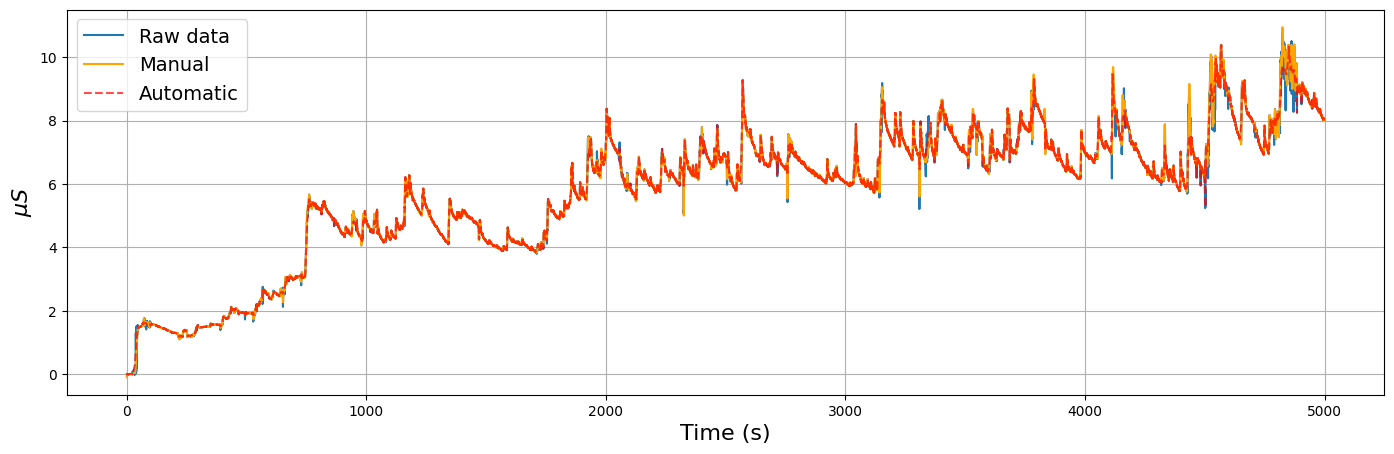

In [105]:
view_time_frame(raw_eda_df, 0, 5000)

the aforementioned data loaded above was just one subject I believe which spans from 0 to roughly 6400 seconds or 1 hour roughly for each subject, because in the edabe dataset which consists of train and test folders, inside each folder are I believe the subjects which each exhibit their skin conductance responses have their last rows have time values of 59, 58, 60, 61, 62, 63, 64 etc. which may tell us that each subject had their SCR recorded from 0 to 6400 seconds which again roughly is 1 hour for each subject

here oxused is the name of the subject as the filename Corrected_oxused_expert2.csv suggests and has been used by llanes-jurado for testing their automatic eda signal correction model this is why Corrected_oxused_expert2.csv is not actually the data used for training in of itself but the test data processed by the automatic eda signal correction model already

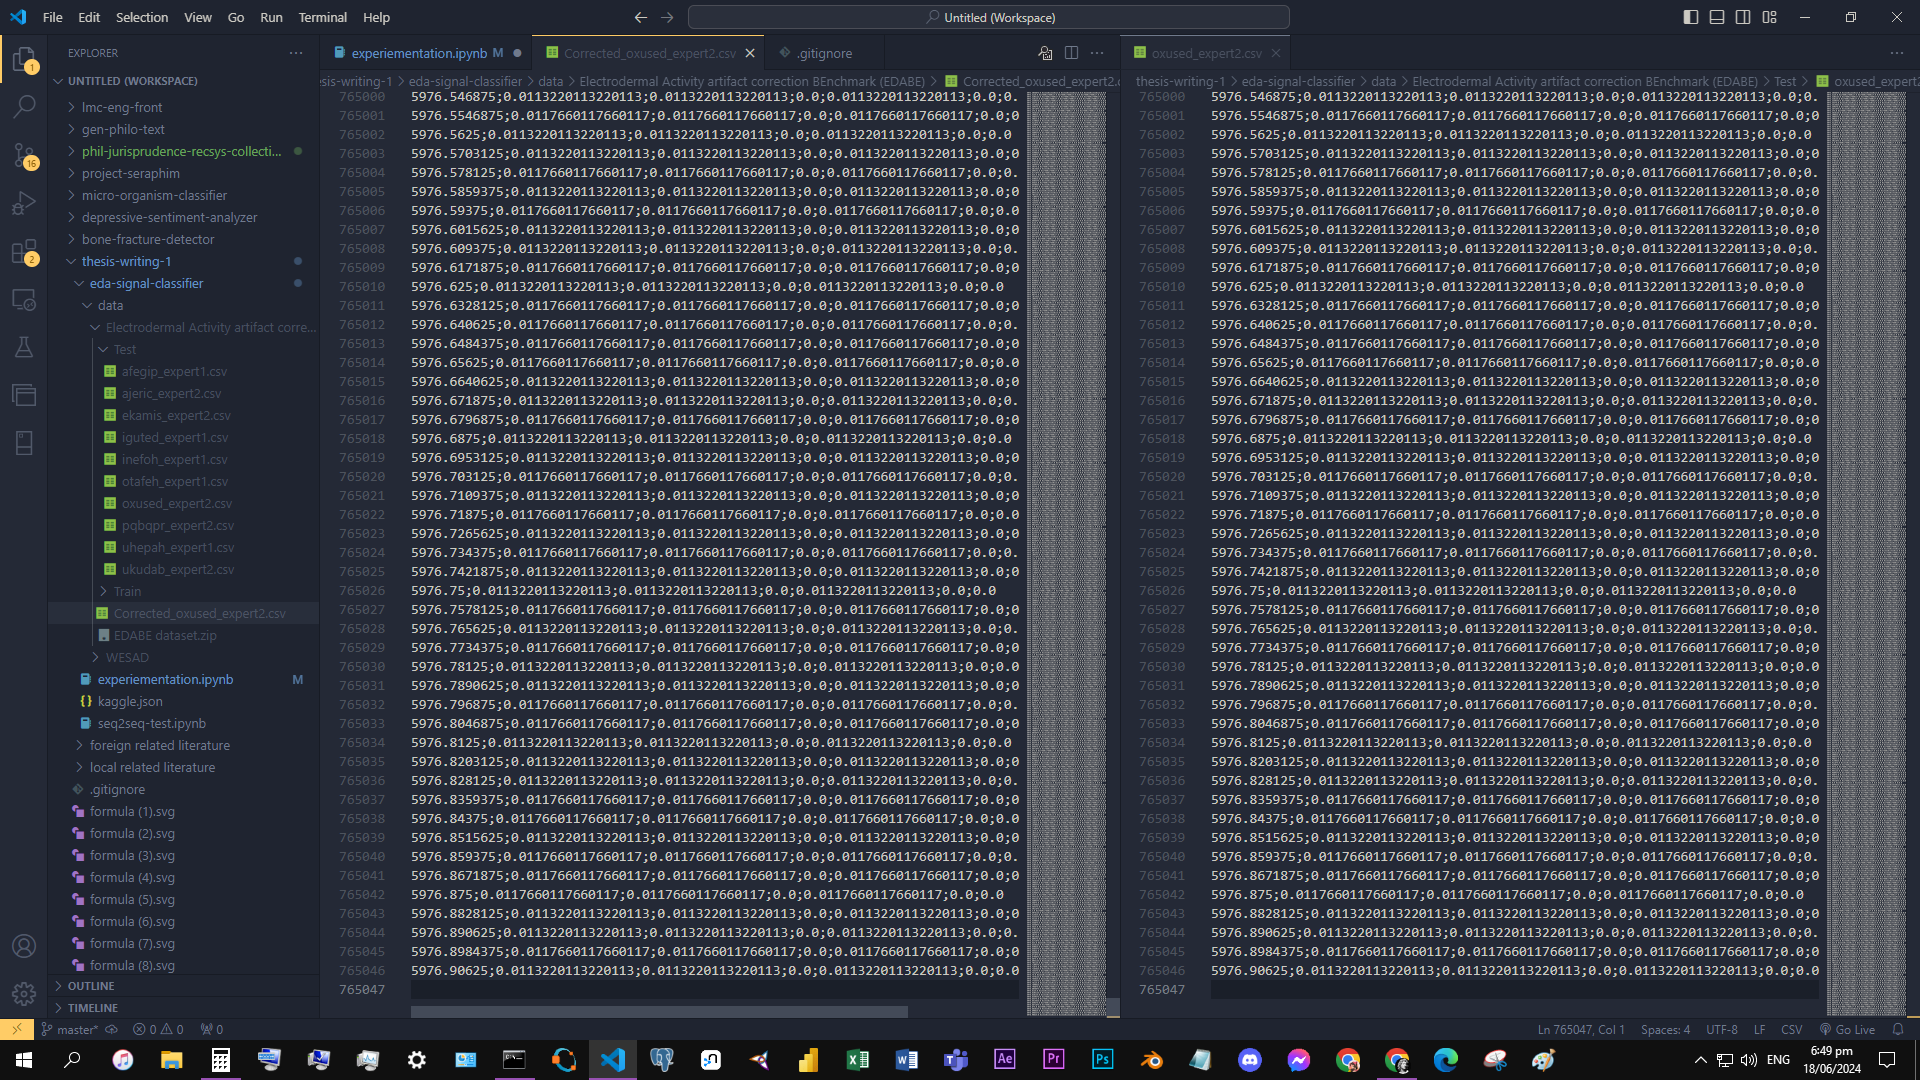

In [106]:
ahixac_eda_df = pd.read_csv('./data/Electrodermal Activity artifact correction BEnchmark (EDABE)/Train/ahixac_expert1.csv', sep=';')
ahixac_eda_df

,time,rawdata,cleandata,binarytarget,signal_automatic,PredArtifacts,PostProcessedPredArtifacts
0,0.000000,0.000000,-0.164015,0.0,2.106994e-20,1.0,1.0
1,0.007812,0.000000,-0.127567,0.0,1.879714e-06,1.0,1.0
2,0.015625,0.000000,-0.127567,0.0,3.656027e-06,1.0,1.0
3,0.023438,0.000000,-0.127567,0.0,5.370973e-06,1.0,1.0
4,0.031250,0.000000,-0.127567,0.0,7.062509e-06,1.0,1.0
...,...,...,...,...,...,...,...
832825,6506.445312,2.591209,2.591209,0.0,2.591209e+00,0.0,0.0
832826,6506.453125,2.585348,2.585348,0.0,2.585348e+00,0.0,0.0
832827,6506.460938,2.602930,2.602930,0.0,2.602930e+00,0.0,0.0
832828,6506.468750,2.570696,2.570696,0.0,2.570696e+00,0.0,0.0


## we need to get the last row of this dataframes time column and round the time (in seconds) to a whole number and that would be the end_time_s value we can use for the `view_time_frame` function

In [107]:
begin_time_s = 0
end_time_s = ahixac_eda_df['time'].iloc[-1]

In [108]:
end_time_s = round(end_time_s)
end_time_s

6506

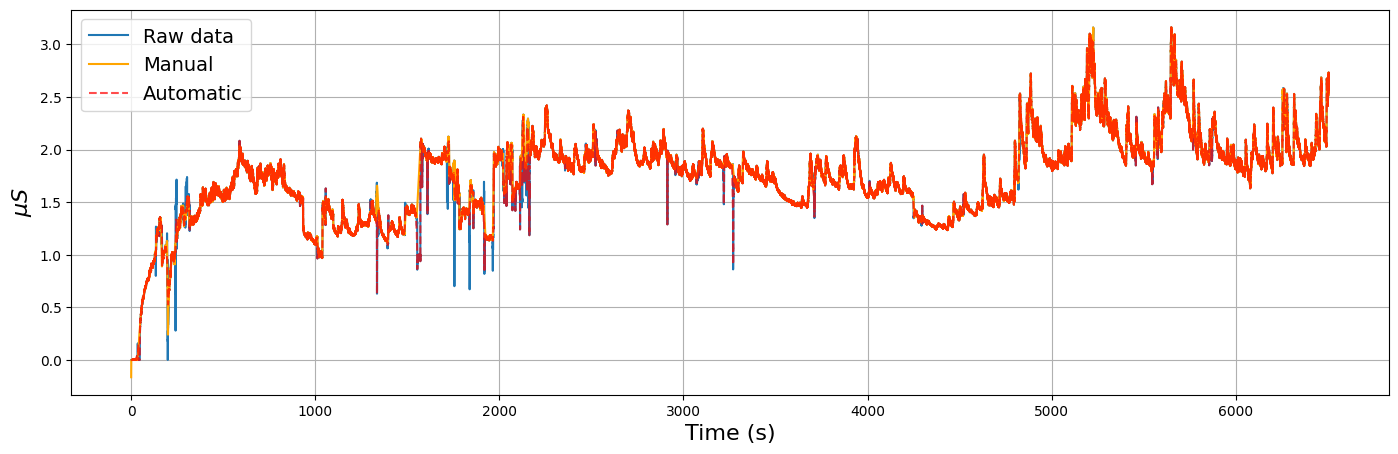

In [109]:
view_time_frame(ahixac_eda_df, begin_time_s, end_time_s)

In [110]:
len(os.listdir('./data/Electrodermal Activity artifact correction BEnchmark (EDABE)/Test/'))

10

In [111]:
len(os.listdir('./data/Electrodermal Activity artifact correction BEnchmark (EDABE)/Train/'))

33

## this also tells us as llanes-jurado et al. (2023) has detailed that in total there were 43 subjects that had their SCR recorded. And this tells us that the test set used 10 subjects, and the train set used 33 subjects

## Things to do and know about the dataset:
- what frequency (in hertz) were the eda signals recorded in in llanes-jurado et al. (2023), because in taylor et al. (2015) it was in 8hz? **128hz**
- visualize a filtered version of the eda signals using taylor et al. function
- print question and answer by gemini about filtering raw eda signals using `scipy.signal.butter` etc.
- once printed write down the function written 

In [135]:
def interpolate_to_8hz(data: pd.DataFrame, sample_rate, start_time):
    """
    interpolates signals to a certain frequency i.e. if an
    eda signal has been recorded at 128hz it can be interpolated
    to 8hz via downsampling or to 256hz via upsampling
    """
    
    # get number of rows of dataframe
    n_rows = data.shape[0]
    if sample_rate < 8:
        if sample_rate == 2:
            # we modify the index of the dataframe to be time values
            data.index = pd.date_range(start=start_time, periods=n_rows, freq='500ms')
        elif sample_rate == 4:
            data.index = pd.date_range(start=start_time, periods=n_rows, freq='250ms')

        # if our sample rate is 1, 3, 5, 6, or 7 which are all below 8 then
        # we convert our timestamps to that that increments to 125 milliseconds 
        # now
        data = data.resample('125ms').mean()
    
    # this is if sample rate is 8 or greater than 8
    else:
        if sample_rate > 8:
            # we create a list of indeces to use as index to access parts 
            # of the dataframe which are at this point still integers
            indeces = list(range(0, n_rows))
            indeces_sampled = indeces[0::int(int(sample_rate) / 8)]
            data = data.iloc[indeces_sampled]
        
        # get number of rows of dataframe which were newly sampled
        sampled_n_rows = data.shape[0]

        # set the index to be 8hz
        data.index = pd.date_range(start=start_time, periods=sampled_n_rows, freq='125ms')

    # since data resampling and then aggregation (i.e. mean, sum, etc.) 
    # from 500ms to 125ms for instance will likely generate empty or 
    # nan values we need to also interpolate these empty values
    data = interpolate_empty_values(data)

    return data

def interpolate_empty_values(data: pd.DataFrame):
    """
    # since data resampling and then aggregation (i.e. mean, sum, etc.) 
    # from 500ms to 125ms for instance will likely generate empty or 
    # nan values we need to also interpolate these empty values
    """

    # instead of DataframeIndex object extract 
    # its original values
    cols = data.columns.values

    for col in cols:
        # loop through each column/feature to use to access
        # series of values in each column to interpolate thems
        data.loc[:, col] = data[col].interpolate()

    return data

## Here we want to create a datetime index for our dataframe that increases by 0.5s or 500 milliseconds

In [115]:
now_500ms_from_now = pd.date_range(start=datetime.datetime.now(), periods=10, freq='500ms')
now_500ms_from_now

DatetimeIndex(['2024-06-24 19:48:53.773822', '2024-06-24 19:48:54.273822',
               '2024-06-24 19:48:54.773822', '2024-06-24 19:48:55.273822',
               '2024-06-24 19:48:55.773822', '2024-06-24 19:48:56.273822',
               '2024-06-24 19:48:56.773822', '2024-06-24 19:48:57.273822',
               '2024-06-24 19:48:57.773822', '2024-06-24 19:48:58.273822'],
              dtype='datetime64[ns]', freq='500ms')

## Here we want to create a datetime index object for our dataframe that increases by 0.25s or 500milliseconds

In [116]:
now_250ms_from_now = pd.date_range(start=datetime.datetime.now(), periods=10, freq='250ms')
now_250ms_from_now

DatetimeIndex(['2024-06-24 19:48:54.204835', '2024-06-24 19:48:54.454835',
               '2024-06-24 19:48:54.704835', '2024-06-24 19:48:54.954835',
               '2024-06-24 19:48:55.204835', '2024-06-24 19:48:55.454835',
               '2024-06-24 19:48:55.704835', '2024-06-24 19:48:55.954835',
               '2024-06-24 19:48:56.204835', '2024-06-24 19:48:56.454835'],
              dtype='datetime64[ns]', freq='250ms')

In [117]:
test_data = pd.Series(range(10), index=now_500ms_from_now)
test_data

2024-06-24 19:48:53.773822    0
2024-06-24 19:48:54.273822    1
2024-06-24 19:48:54.773822    2
2024-06-24 19:48:55.273822    3
2024-06-24 19:48:55.773822    4
2024-06-24 19:48:56.273822    5
2024-06-24 19:48:56.773822    6
2024-06-24 19:48:57.273822    7
2024-06-24 19:48:57.773822    8
2024-06-24 19:48:58.273822    9
Freq: 500ms, dtype: int64

In [118]:
test_data_resampled = test_data.resample('125ms')
test_data_resampled

In [119]:
len(test_data_resampled)

37

In [120]:
for row in test_data_resampled:
    print(row)

(Timestamp('2024-06-24 19:48:53.750000'), 2024-06-24 19:48:53.773822    0
Freq: 500ms, dtype: int64)
(Timestamp('2024-06-24 19:48:53.875000'), Series([], Freq: 500ms, dtype: int64))
(Timestamp('2024-06-24 19:48:54'), Series([], Freq: 500ms, dtype: int64))
(Timestamp('2024-06-24 19:48:54.125000'), Series([], Freq: 500ms, dtype: int64))
(Timestamp('2024-06-24 19:48:54.250000'), 2024-06-24 19:48:54.273822    1
Freq: 500ms, dtype: int64)
(Timestamp('2024-06-24 19:48:54.375000'), Series([], Freq: 500ms, dtype: int64))
(Timestamp('2024-06-24 19:48:54.500000'), Series([], Freq: 500ms, dtype: int64))
(Timestamp('2024-06-24 19:48:54.625000'), Series([], Freq: 500ms, dtype: int64))
(Timestamp('2024-06-24 19:48:54.750000'), 2024-06-24 19:48:54.773822    2
Freq: 500ms, dtype: int64)
(Timestamp('2024-06-24 19:48:54.875000'), Series([], Freq: 500ms, dtype: int64))
(Timestamp('2024-06-24 19:48:55'), Series([], Freq: 500ms, dtype: int64))
(Timestamp('2024-06-24 19:48:55.125000'), Series([], Freq: 500m

In [121]:
test_data_resampled.mean()

2024-06-24 19:48:53.750    0.0
2024-06-24 19:48:53.875    NaN
2024-06-24 19:48:54.000    NaN
2024-06-24 19:48:54.125    NaN
2024-06-24 19:48:54.250    1.0
2024-06-24 19:48:54.375    NaN
2024-06-24 19:48:54.500    NaN
2024-06-24 19:48:54.625    NaN
2024-06-24 19:48:54.750    2.0
2024-06-24 19:48:54.875    NaN
2024-06-24 19:48:55.000    NaN
2024-06-24 19:48:55.125    NaN
2024-06-24 19:48:55.250    3.0
2024-06-24 19:48:55.375    NaN
2024-06-24 19:48:55.500    NaN
2024-06-24 19:48:55.625    NaN
2024-06-24 19:48:55.750    4.0
2024-06-24 19:48:55.875    NaN
2024-06-24 19:48:56.000    NaN
2024-06-24 19:48:56.125    NaN
2024-06-24 19:48:56.250    5.0
2024-06-24 19:48:56.375    NaN
2024-06-24 19:48:56.500    NaN
2024-06-24 19:48:56.625    NaN
2024-06-24 19:48:56.750    6.0
2024-06-24 19:48:56.875    NaN
2024-06-24 19:48:57.000    NaN
2024-06-24 19:48:57.125    NaN
2024-06-24 19:48:57.250    7.0
2024-06-24 19:48:57.375    NaN
2024-06-24 19:48:57.500    NaN
2024-06-24 19:48:57.625    NaN
2024-06-

In [122]:
len(test_data_resampled.mean())

37

In [123]:
akakip_eda_df = pd.read_csv('./data/Electrodermal Activity artifact correction BEnchmark (EDABE)/Train/akakip_expert2.csv', sep=';')
akakip_eda_df

,time,rawdata,cleandata,binarytarget,signal_automatic,PredArtifacts,PostProcessedPredArtifacts
0,0.000000,0.000000,-0.164015,0.0,2.106994e-20,1.0,1.0
1,0.007812,0.000000,-0.164015,0.0,1.879714e-06,1.0,1.0
2,0.015625,0.000000,-0.164015,0.0,3.656027e-06,1.0,1.0
3,0.023438,0.000000,-0.164015,0.0,5.370973e-06,1.0,1.0
4,0.031250,0.000000,-0.164015,0.0,7.062509e-06,1.0,1.0
...,...,...,...,...,...,...,...
770809,6021.945312,5.214994,5.214994,0.0,5.214994e+00,0.0,0.0
770810,6021.953125,5.209889,5.209889,0.0,5.209889e+00,0.0,0.0
770811,6021.960938,5.209889,5.209889,0.0,5.209889e+00,0.0,0.0
770812,6021.968750,5.204784,5.204784,0.0,5.204784e+00,0.0,0.0


In [124]:
akakip_eda_df.columns

Index(['time', 'rawdata', 'cleandata', 'binarytarget', 'signal_automatic',
       'PredArtifacts', 'PostProcessedPredArtifacts'],
      dtype='object')

## skiprows argument in reading a `.csv` file skips rows `n` times specified by user e.g. if we have a set of data `[1, 2, 3, 4, 5]` and I specify `skiprows` to be 2 then only 3, 4, 5 will be left since I skipped the first 2 elements namely 1 and 2. 

In [125]:
akakip_eda_df = pd.read_csv('./data/Electrodermal Activity artifact correction BEnchmark (EDABE)/Train/akakip_expert2.csv', sep=';', skiprows=2)
akakip_eda_df

,0.0078125,0.0,-0.1640150893882231,0.0.1,1.8797143901969444e-06,1.0,1.0.1
0,0.015625,0.000000,-0.164015,0.0,0.000004,1.0,1.0
1,0.023438,0.000000,-0.164015,0.0,0.000005,1.0,1.0
2,0.031250,0.000000,-0.164015,0.0,0.000007,1.0,1.0
3,0.039062,0.000000,-0.164015,0.0,0.000009,1.0,1.0
4,0.046875,0.000000,-0.164015,0.0,0.000010,1.0,1.0
...,...,...,...,...,...,...,...
770807,6021.945312,5.214994,5.214994,0.0,5.214994,0.0,0.0
770808,6021.953125,5.209889,5.209889,0.0,5.209889,0.0,0.0
770809,6021.960938,5.209889,5.209889,0.0,5.209889,0.0,0.0
770810,6021.968750,5.204784,5.204784,0.0,5.204784,0.0,0.0


## since the last skipped row became the headers we can just reset the headers via the setter function of our dataframe object

In [126]:
akakip_eda_df.columns = ['time', 'signal', 'clean_signal', 'label', 'auto_signal', 'pred_art', 'post_proc_pred_art']
akakip_eda_df

,time,signal,clean_signal,label,auto_signal,pred_art,post_proc_pred_art
0,0.015625,0.000000,-0.164015,0.0,0.000004,1.0,1.0
1,0.023438,0.000000,-0.164015,0.0,0.000005,1.0,1.0
2,0.031250,0.000000,-0.164015,0.0,0.000007,1.0,1.0
3,0.039062,0.000000,-0.164015,0.0,0.000009,1.0,1.0
4,0.046875,0.000000,-0.164015,0.0,0.000010,1.0,1.0
...,...,...,...,...,...,...,...
770807,6021.945312,5.214994,5.214994,0.0,5.214994,0.0,0.0
770808,6021.953125,5.209889,5.209889,0.0,5.209889,0.0,0.0
770809,6021.960938,5.209889,5.209889,0.0,5.209889,0.0,0.0
770810,6021.968750,5.204784,5.204784,0.0,5.204784,0.0,0.0


In [127]:
# get start time of subjects eda signals
akakip_start_time = akakip_eda_df['time'].iloc[0]
akakip_start_time

0.015625

In [128]:
# to convert this to a pandas datetime object we need to specify the unit of the original object which is our start time
akakip_start_time = pd.to_datetime(akakip_start_time, unit='s')
akakip_start_time

Timestamp('1970-01-01 00:00:00.015625')

## now we can use the start time we extracted earlier and use the number of rows from the shape of our dataframe to create dataframe indeces that increment in 500, 250, and 125 milliseconds respectively

In [129]:
akakip_500ms = pd.date_range(start=akakip_start_time, periods=akakip_eda_df.shape[0], freq='500ms')
akakip_500ms

DatetimeIndex(['1970-01-01 00:00:00.015625', '1970-01-01 00:00:00.515625',
               '1970-01-01 00:00:01.015625', '1970-01-01 00:00:01.515625',
               '1970-01-01 00:00:02.015625', '1970-01-01 00:00:02.515625',
               '1970-01-01 00:00:03.015625', '1970-01-01 00:00:03.515625',
               '1970-01-01 00:00:04.015625', '1970-01-01 00:00:04.515625',
               ...
               '1970-01-05 11:03:21.015625', '1970-01-05 11:03:21.515625',
               '1970-01-05 11:03:22.015625', '1970-01-05 11:03:22.515625',
               '1970-01-05 11:03:23.015625', '1970-01-05 11:03:23.515625',
               '1970-01-05 11:03:24.015625', '1970-01-05 11:03:24.515625',
               '1970-01-05 11:03:25.015625', '1970-01-05 11:03:25.515625'],
              dtype='datetime64[ns]', length=770812, freq='500ms')

In [130]:
akakip_250ms = pd.date_range(start=akakip_start_time, periods=akakip_eda_df.shape[0], freq='250ms')
akakip_250ms

DatetimeIndex(['1970-01-01 00:00:00.015625', '1970-01-01 00:00:00.265625',
               '1970-01-01 00:00:00.515625', '1970-01-01 00:00:00.765625',
               '1970-01-01 00:00:01.015625', '1970-01-01 00:00:01.265625',
               '1970-01-01 00:00:01.515625', '1970-01-01 00:00:01.765625',
               '1970-01-01 00:00:02.015625', '1970-01-01 00:00:02.265625',
               ...
               '1970-01-03 05:31:40.515625', '1970-01-03 05:31:40.765625',
               '1970-01-03 05:31:41.015625', '1970-01-03 05:31:41.265625',
               '1970-01-03 05:31:41.515625', '1970-01-03 05:31:41.765625',
               '1970-01-03 05:31:42.015625', '1970-01-03 05:31:42.265625',
               '1970-01-03 05:31:42.515625', '1970-01-03 05:31:42.765625'],
              dtype='datetime64[ns]', length=770812, freq='250ms')

In [131]:
akakip_125ms = pd.date_range(start=akakip_start_time, periods=akakip_eda_df.shape[0], freq='125ms')
akakip_125ms

DatetimeIndex(['1970-01-01 00:00:00.015625', '1970-01-01 00:00:00.140625',
               '1970-01-01 00:00:00.265625', '1970-01-01 00:00:00.390625',
               '1970-01-01 00:00:00.515625', '1970-01-01 00:00:00.640625',
               '1970-01-01 00:00:00.765625', '1970-01-01 00:00:00.890625',
               '1970-01-01 00:00:01.015625', '1970-01-01 00:00:01.140625',
               ...
               '1970-01-02 02:45:50.265625', '1970-01-02 02:45:50.390625',
               '1970-01-02 02:45:50.515625', '1970-01-02 02:45:50.640625',
               '1970-01-02 02:45:50.765625', '1970-01-02 02:45:50.890625',
               '1970-01-02 02:45:51.015625', '1970-01-02 02:45:51.140625',
               '1970-01-02 02:45:51.265625', '1970-01-02 02:45:51.390625'],
              dtype='datetime64[ns]', length=770812, freq='125ms')

In [136]:
interpolate_to_8hz(akakip_eda_df, sample_rate=128, start_time=akakip_start_time)

,time,signal,clean_signal,label,auto_signal,pred_art,post_proc_pred_art
1970-01-01 00:00:00.015625,0.015625,0.000000,-0.164015,0.0,0.000004,1.0,1.0
1970-01-01 00:00:00.140625,0.140625,0.000000,-0.028079,0.0,0.000031,1.0,1.0
1970-01-01 00:00:00.265625,0.265625,0.000222,0.000222,0.0,0.000144,1.0,1.0
1970-01-01 00:00:00.390625,0.390625,0.000222,0.000222,0.0,0.000199,1.0,1.0
1970-01-01 00:00:00.515625,0.515625,0.000222,0.000222,0.0,0.000221,0.0,0.0
...,...,...,...,...,...,...,...
1970-01-01 01:40:21.390625,6021.390625,5.352835,5.352835,0.0,5.352835,0.0,0.0
1970-01-01 01:40:21.515625,6021.515625,5.317099,5.317099,0.0,5.317099,0.0,0.0
1970-01-01 01:40:21.640625,6021.640625,5.286467,5.286467,0.0,5.286467,0.0,0.0
1970-01-01 01:40:21.765625,6021.765625,5.250731,5.250731,0.0,5.250731,0.0,0.0


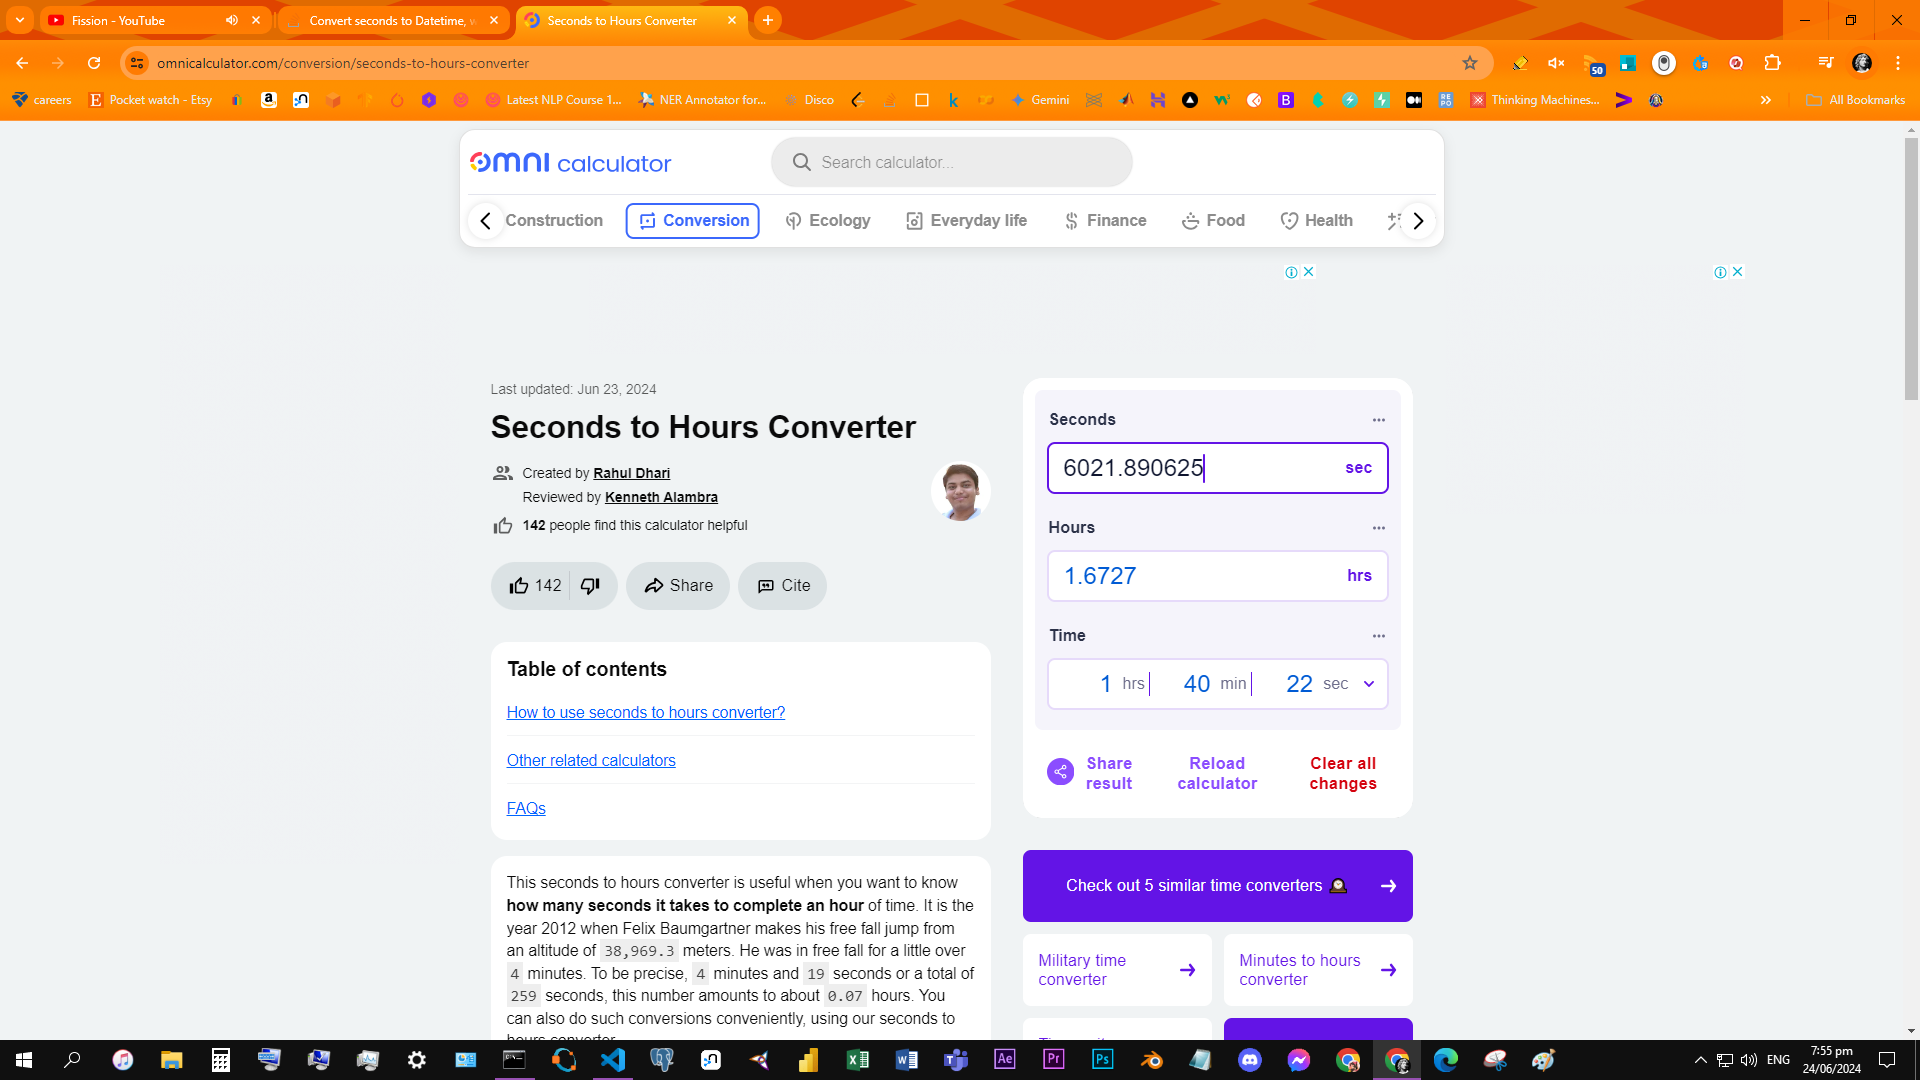